# JAWAD HASSAN
# 2230-0035
# BS AI
# ML
# LAB 08
# Principle Component Analysis

### Datasets Used:
[Red Wine Quality Dataset](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In [41]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [9]:
#lab activity
cancer=load_breast_cancer()
print(cancer.keys())
print(cancer['DESCR'])
df=pd.DataFrame(cancer['data'],columns=cancer['feature_names'])

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 f

In [10]:
print(df.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [12]:
scalar=StandardScaler()
dfscaled=scalar.fit_transform(df)
dfscaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [ ]:
pca=PCA(n_components=2)
dfpca=pca.fit_transform(dfscaled)
print(dfpca.shape)
print(dfscaled.shape)


(569, 2)
(569, 30)


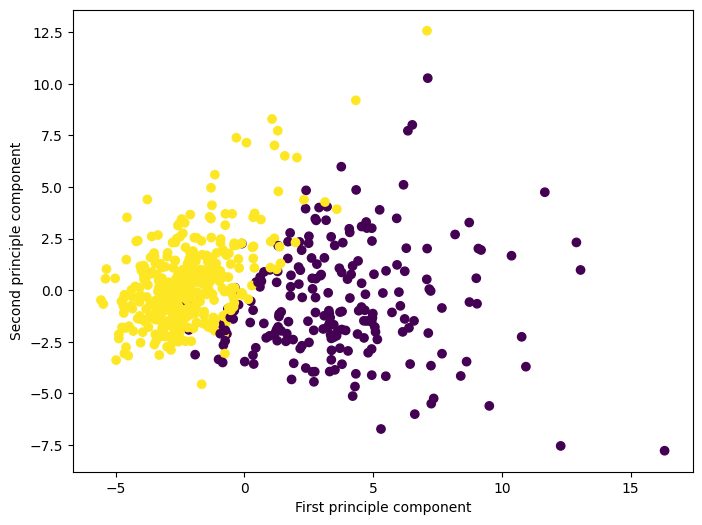

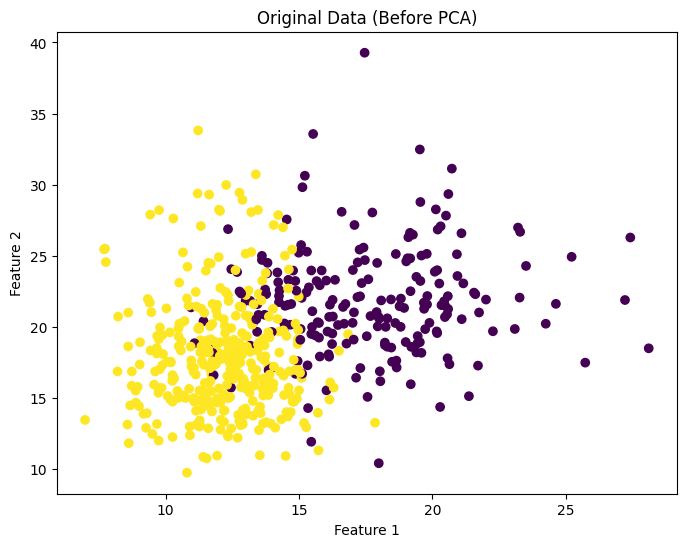

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(dfpca[:,0],dfpca[:,1],c=cancer['target'])
plt.xlabel('First principle component')
plt.ylabel('Second principle component')

plt.figure(figsize=(8,6))
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=cancer['target'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Data (Before PCA)')
plt.show()


In [36]:
#task1 - Apply PCA on Wine Dataset
#load dataset
df=pd.read_csv("/Users/macbook/Desktop/sem6/ML/lab8/git8/winequality-red.csv")
print(df.head(5)) 
#11 features and quality is target variable
#explore
print(df.columns)
print(df.shape)
#scaling needed since features have wide range from 34 to 0.076 which is huge difference
scalar=StandardScaler()
x=df.drop('quality',axis=1)
y=df['quality']
xscaled=scalar.fit_transform(x)
print(xscaled)
#apply pca
#2 components
pca2=PCA(n_components=2)
p2=pca2.fit_transform(xscaled)
print(p2)
# 3 components
pca3=PCA(n_components=3)
p3=pca3.fit_transform(xscaled)
print(p3)
#before shape
print(xscaled.shape)
#transform data
print(p2.shape)
print(p3.shape)



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [33]:
#compare:
# For 2 Components
print("Variance explained by 2 components:", pca2.explained_variance_ratio_)
print("Total variance (2 components):", sum(pca2.explained_variance_ratio_) * 100, "%")

# For 3 Components
print("Variance explained by 3 components:", pca3.explained_variance_ratio_)
print("Total variance (3 components):", sum(pca3.explained_variance_ratio_) * 100, "%")

Variance explained by 2 components: [0.28173931 0.1750827 ]
Total variance (2 components): 45.682201184294044 %
Variance explained by 3 components: [0.28173931 0.1750827  0.1409585 ]
Total variance (3 components): 59.77805108224621 %


### Comparison:
2 components capture 45 percent of info gain and 3 components capture 60 percent so almost 15 percent more info gain so 3 components is better.
### Understand Output:
In the Red Wine dataset, the PCs are "blends" of your original features. While PCA is math-heavy, the components usually represent these physical wine characteristics:
#### PC1: The Acidity and Density Axis, most important and highest variance captured
#### PC2: The Fermentation/Volatiles Axis, second highest variance captured

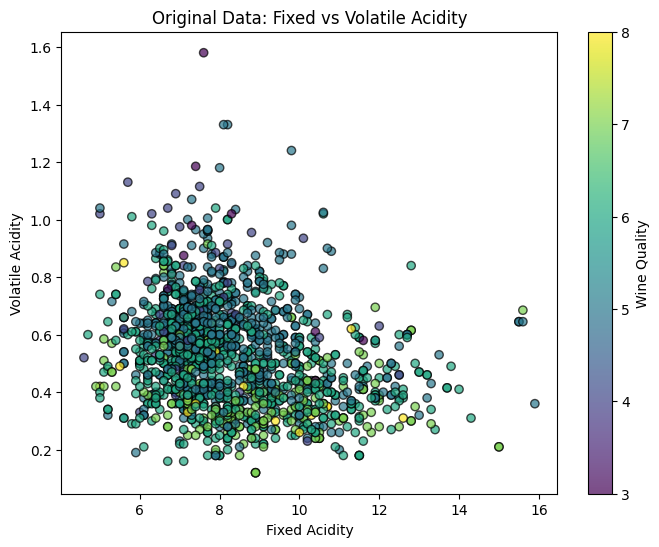

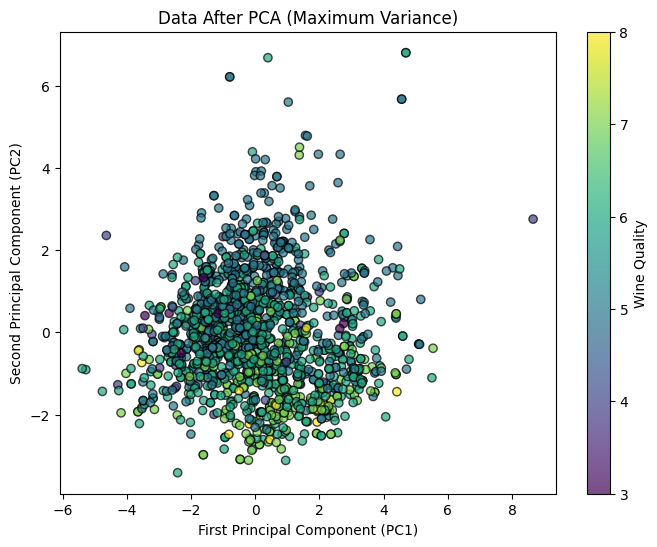

In [37]:
#visualize before pca:
plt.figure(figsize=(8,6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
plt.xlabel('Fixed Acidity')
plt.ylabel('Volatile Acidity')
plt.title('Original Data: Fixed vs Volatile Acidity')
plt.colorbar(label='Wine Quality')
plt.show()

#visualize after pca:
# Visualize After PCA
plt.figure(figsize=(8,6))
plt.scatter(p2[:, 0], p2[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title('Data After PCA (Maximum Variance)')
plt.colorbar(label='Wine Quality')
plt.show()

### Conclusion:
PCA successfully re-centered and re-rotated the 11-dimensional data to show the maximum possible variance on a 2D screen, hence the dimensions are reduced and only important information is preserved.

In [54]:
#task 2 Apply LDA (Linear Discriminant Analysis) on Wine Dataset
def quality_label(x):
    if x <= 5:
        return 'low'
    elif x == 6:
        return 'medium'
    else:
        return 'high'

df['label'] = df['quality'].apply(quality_label)
lda =LinearDiscriminantAnalysis(n_components=2) #no. of classes -1, we have 3 classes
y=df['label']
ldascale=lda.fit_transform(xscaled,y)# in lda we give labels
print(ldascale.shape)

info_gain = lda.explained_variance_ratio_

print(f"Information Gain by LD1: {info_gain[0]*100:.2f}%")
print(f"Information Gain by LD2: {info_gain[1]*100:.2f}%")
print(f"Total Info from LD1 & LD2: {sum(info_gain[:2])*100:.2f}%")


(1599, 2)
Information Gain by LD1: 96.31%
Information Gain by LD2: 3.69%
Total Info from LD1 & LD2: 100.00%


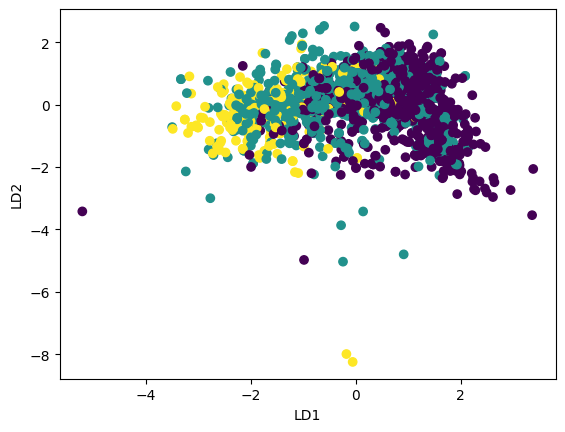

In [52]:
#plot results visual:
plt.scatter(ldascale[:,0], ldascale[:,1], c=pd.factorize(y)[0])
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

### Comparison:
### Which method separates classes better?
#### lda separates classes better 
### Why does LDA perform better for classification?
#### This LDA (Linear Discriminant Analysis) result is much more revealing than the PCA plot. While  PCA plot was a dense, circular cloud, this LDA plot shows clear directional separation. We can actually see the model stretching the different qualities apart.
### What role do labels play in LDA?
#### In the LDA plot, the labels allowed the model to figure out that Alcohol and Volatile Acidity are the best separators. If we hadn't provided the quality labels, the model might have focused on Sulfur Dioxide just because it has a lot of variance, even if it doesn't help distinguish a good wine from a bad one.